In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Ruta relativa al dataset de clustering (debe ser generado por feature_engineering.ipynb)
ruta = os.path.join('data', 'final', 'user_clustering_dataset.csv')

if not os.path.exists(ruta):
    raise FileNotFoundError(f'No existe {ruta}. Ejecuta feature_engineering.ipynb primero.')

user_df = pd.read_csv(ruta)
user_df.head()

,user_id,total_events,unique_products,view,cart,purchase,avg_price,avg_events_per_product,avg_purchase_price,weighted_score,...,pct_morning,pct_afternoon,pct_evening,pct_night,pct_weekday,pct_weekend,proportion_tech,proportion_fashion_lifestyle,proportion_home,proportion_welfare
0,1515915625353226922,1,1,1,0,0,76.480000,1.0,0.0,1,...,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0
1,1515915625353230067,1,1,1,0,0,28.980000,1.0,0.0,1,...,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.0,0.0,1.0,0.0
2,1515915625353230683,13,10,13,0,0,62.686923,1.3,0.0,13,...,1.000000,0.000000,0.0,0.000000,0.923077,0.076923,1.0,0.0,0.0,0.0
3,1515915625353230922,1,1,1,0,0,274.400000,1.0,0.0,1,...,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0
4,1515915625353234047,36,8,36,0,0,152.275000,4.5,0.0,36,...,0.861111,0.111111,0.0,0.027778,0.777778,0.222222,1.0,0.0,0.0,0.0


# Gaussian Mixture Model Clustering (K=2)

**Objetivo:** Clasificar usuarios en 2 grupos: ACTIVO vs PASIVO  
**Input:** `data/final/user_clustering_dataset.csv`  
**Output:** `data/final/user_clustering_gmm_results.csv`

## Notas sobre rutas:
- ✅ Todas las rutas son **relativas** y portables
- ✅ El notebook funciona desde cualquier máquina descargando el proyecto
- ✅ Requiere: `data/final/` con los CSVs de feature_engineering.ipynb
- ⚠️ Ejecuta siempre desde la raíz del proyecto (donde está este notebook)

In [18]:
#Revisar estructura básica
print(user_df.shape)
print(user_df.columns)
user_df.info()

(407237, 21)
Index(['user_id', 'total_events', 'unique_products', 'view', 'cart',
       'purchase', 'avg_price', 'avg_events_per_product', 'avg_purchase_price',
       'weighted_score', 'recency_days', 'pct_morning', 'pct_afternoon',
       'pct_evening', 'pct_night', 'pct_weekday', 'pct_weekend',
       'proportion_tech', 'proportion_fashion_lifestyle', 'proportion_home',
       'proportion_welfare'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 407237 entries, 0 to 407236
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       407237 non-null  int64  
 1   total_events                  407237 non-null  int64  
 2   unique_products               407237 non-null  int64  
 3   view                          407237 non-null  int64  
 4   cart                          407237 non-null  int64  
 5   purchase                      407237 non-null  in

In [19]:
#Separar users_id de las variables del clustering

user_ids = user_df["user_id"]

X = user_df.drop(columns=["user_id"])

#Escalar variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,total_events,unique_products,view,cart,purchase,avg_price,avg_events_per_product,avg_purchase_price,weighted_score,recency_days,pct_morning,pct_afternoon,pct_evening,pct_night,pct_weekday,pct_weekend,proportion_tech,proportion_fashion_lifestyle,proportion_home,proportion_welfare
0,-0.265912,-0.234842,-0.248157,-0.197284,-0.164413,-0.180015,-0.314030,-0.144063,-0.269618,0.960042,1.443132,-0.735956,-0.526995,-0.370665,0.622188,-0.622188,0.634703,-0.218818,-0.562774,-0.03605
1,-0.265912,-0.234842,-0.248157,-0.197284,-0.164413,-0.341964,-0.314030,-0.144063,-0.269618,1.467451,1.443132,-0.735956,-0.526995,-0.370665,0.622188,-0.622188,-1.591461,-0.218818,1.795321,-0.03605
2,2.457912,5.526393,2.895960,-0.197284,-0.164413,-0.227042,-0.129015,-0.144063,1.905370,-0.010654,1.443132,-0.735956,-0.526995,-0.370665,0.445993,-0.445993,0.634703,-0.218818,-0.562774,-0.03605
3,-0.265912,-0.234842,-0.248157,-0.197284,-0.164413,0.494781,-0.314030,-0.144063,-0.269618,1.555696,1.443132,-0.735956,-0.526995,-0.370665,0.622188,-0.622188,0.634703,-0.218818,-0.562774,-0.03605
4,7.678574,4.246118,8.922186,-0.197284,-0.164413,0.078403,1.844478,-0.144063,6.074095,-1.510820,1.141320,-0.494770,-0.526995,-0.281692,0.113180,-0.113180,0.634703,-0.218818,-0.562774,-0.03605


In [20]:
#EVALUAR GMM entre K=1 y K=10

k_values = range(1, 11)

bic_scores = []
aic_scores = []
models = {}

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5
    )
    
    gmm.fit(X_scaled)
    
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    models[k] = gmm

In [21]:
#CREAR TABLA AIC/BIC

gmm_results = pd.DataFrame({
    "k": list(k_values),
    "BIC": bic_scores,
    "AIC": aic_scores
})

gmm_results

,k,BIC,AIC
0,1,-6.717499e+06,-6.720010e+06
1,2,-3.081312e+07,-3.081815e+07
2,3,-3.298373e+07,-3.299128e+07
3,4,-3.718426e+07,-3.719433e+07
4,5,-4.284397e+07,-4.285657e+07
5,6,-4.196295e+07,-4.197807e+07
6,7,-4.649444e+07,-4.651208e+07
7,8,-5.128118e+07,-5.130134e+07
8,9,-5.236449e+07,-5.238718e+07
9,10,-5.371321e+07,-5.373842e+07


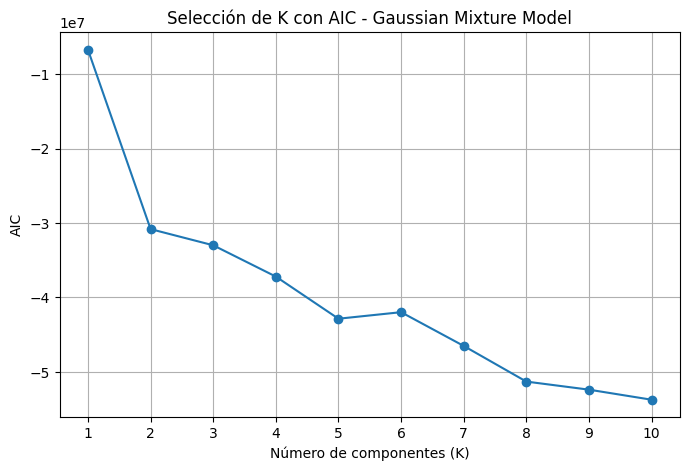

In [22]:
#GRAFICAR AIC
plt.figure(figsize=(8, 5))
plt.plot(gmm_results["k"], gmm_results["AIC"], marker="o")
plt.xlabel("Número de componentes (K)")
plt.ylabel("AIC")
plt.title("Selección de K con AIC - Gaussian Mixture Model")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

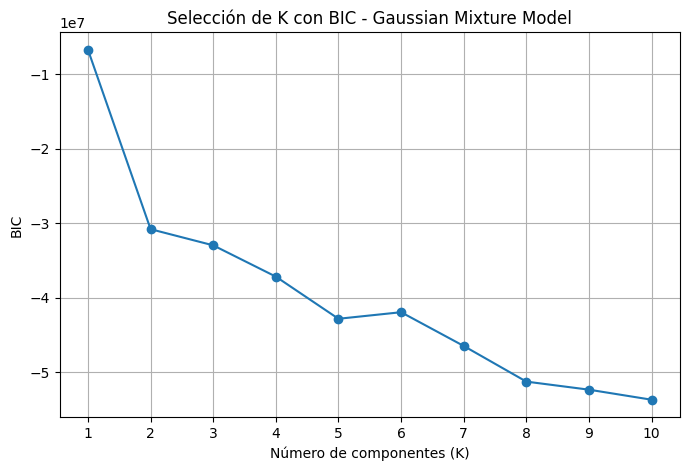

In [23]:
#GRAFICAR BIC
plt.figure(figsize=(8, 5))

plt.plot(
    gmm_results["k"],
    gmm_results["BIC"],
    marker="o"
)

plt.xlabel("Número de componentes (K)")
plt.ylabel("BIC")
plt.title("Selección de K con BIC - Gaussian Mixture Model")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [24]:
#ESTIMAR INDICE SILUETA CON MUESTRA DE 10.000
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5
    )

    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)
    print(f"K={k} | Silhouette={score:.4f}")

K=2 | Silhouette=0.3723
K=3 | Silhouette=0.2031
K=4 | Silhouette=0.1235
K=5 | Silhouette=0.1505
K=6 | Silhouette=0.2492
K=7 | Silhouette=0.1806
K=8 | Silhouette=0.1933
K=9 | Silhouette=0.2251
K=10 | Silhouette=0.2285


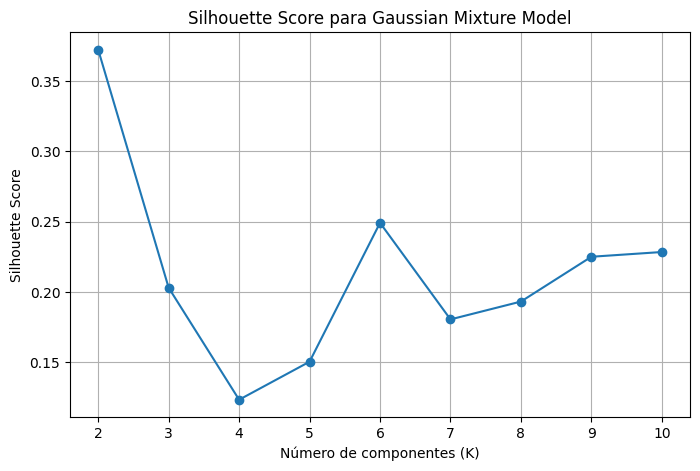

In [25]:
#GRAFICAR INDICE SILUETA
plt.figure(figsize=(8,5))

plt.plot(
    list(k_values_silhouette),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Número de componentes (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para Gaussian Mixture Model")

plt.xticks(list(k_values_silhouette))
plt.grid(True)

plt.show()

El AIC y BIC muestran dos puntos ambiguos de inflexión en K=2 y en K=6. El indice de silueta ayuda a aclarar esta ambiguedad, efectivamente mostrando dos picos en 2 y en 6, pero indicando que en K=2 hay un valor mucho mas alto, y superando el umbral de 0.25 indicando que hay agrupación moderada.

In [26]:
#ENTRENAR MODELO FINAL USANDO EL K=2
k_optimo = 2

gmm_final = GaussianMixture(
    n_components=k_optimo,
    covariance_type="full",
    random_state=42,
    n_init=5
)

gmm_final.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",5
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [ ]:
import joblib

os.makedirs('models', exist_ok=True)
joblib.dump(gmm_final, 'models/gmm_k2.pkl')
print("Modelo GMM guardado: models/gmm_k2.pkl")

In [27]:
#Asignar Cluster y probabilidad de pertenencia
clusters = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)

user_df_gmm = user_df.copy()

user_df_gmm["gmm_cluster"] = clusters
user_df_gmm["cluster_confidence"] = cluster_probs.max(axis=1)

user_df_gmm.head()

,user_id,total_events,unique_products,view,cart,purchase,avg_price,avg_events_per_product,avg_purchase_price,weighted_score,...,pct_evening,pct_night,pct_weekday,pct_weekend,proportion_tech,proportion_fashion_lifestyle,proportion_home,proportion_welfare,gmm_cluster,cluster_confidence
0,1515915625353226922,1,1,1,0,0,76.480000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1,1.0
1,1515915625353230067,1,1,1,0,0,28.980000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,0.0,0.0,1.0,0.0,1,1.0
2,1515915625353230683,13,10,13,0,0,62.686923,1.3,0.0,13,...,0.0,0.000000,0.923077,0.076923,1.0,0.0,0.0,0.0,0,1.0
3,1515915625353230922,1,1,1,0,0,274.400000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1,1.0
4,1515915625353234047,36,8,36,0,0,152.275000,4.5,0.0,36,...,0.0,0.027778,0.777778,0.222222,1.0,0.0,0.0,0.0,0,1.0


In [28]:
#Ver tamaño de cada cluster
user_df_gmm["gmm_cluster"].value_counts().sort_index()

gmm_cluster
0     56351
1    350886
Name: count, dtype: int64

In [29]:
#Resumen promedio por cluster
cluster_summary = user_df_gmm.groupby("gmm_cluster").mean(numeric_only=True)

cluster_summary

,user_id,total_events,unique_products,view,cart,purchase,avg_price,avg_events_per_product,avg_purchase_price,weighted_score,...,pct_afternoon,pct_evening,pct_night,pct_weekday,pct_weekend,proportion_tech,proportion_fashion_lifestyle,proportion_home,proportion_welfare,cluster_confidence
gmm_cluster,,,,,,,,,,,,,,,,,,,,,
0,1.515916e+18,6.645738,2.601462,5.213785,0.769268,0.662686,177.642298,3.046740,51.718555,8.740377,...,0.340662,0.208361,0.106007,0.730546,0.269454,0.545926,0.326411,0.118356,0.009307,0.997931
1,1.515916e+18,1.452945,1.168590,1.422516,0.030429,0.000000,121.512148,1.262273,0.000000,1.483374,...,0.338786,0.209492,0.117284,0.728015,0.271985,0.742024,0.000000,0.257976,0.000000,0.999850


In [30]:
#Exportar csv con clusters
os.makedirs(os.path.join('data', 'final'), exist_ok=True)
ruta_salida = os.path.join('data', 'final', 'user_clustering_gmm_results.csv')

user_df_gmm.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print("Archivo exportado en:")
print(ruta_salida)

Archivo exportado en:
data/final/user_clustering_gmm_results.csv


In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# CARGAR CSV EXPORTADO (ruta relativa portátil)
ruta = os.path.join('data', 'final', 'user_clustering_gmm_results.csv')

if not os.path.exists(ruta):
    raise FileNotFoundError(f'No existe {ruta}. Ejecuta la celda anterior de exportación primero.')

df_gmm = pd.read_csv(ruta)
df_gmm.head()

,user_id,total_events,unique_products,view,cart,purchase,avg_price,avg_events_per_product,avg_purchase_price,weighted_score,...,pct_evening,pct_night,pct_weekday,pct_weekend,proportion_tech,proportion_fashion_lifestyle,proportion_home,proportion_welfare,gmm_cluster,cluster_confidence
0,1515915625353226922,1,1,1,0,0,76.480000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1,1.0
1,1515915625353230067,1,1,1,0,0,28.980000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,0.0,0.0,1.0,0.0,1,1.0
2,1515915625353230683,13,10,13,0,0,62.686923,1.3,0.0,13,...,0.0,0.000000,0.923077,0.076923,1.0,0.0,0.0,0.0,0,1.0
3,1515915625353230922,1,1,1,0,0,274.400000,1.0,0.0,1,...,0.0,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1,1.0
4,1515915625353234047,36,8,36,0,0,152.275000,4.5,0.0,36,...,0.0,0.027778,0.777778,0.222222,1.0,0.0,0.0,0.0,0,1.0


In [34]:
#SEPARAR FEATURES (NO QUEREMOS ID, GMM CLUSTER y CLUSTER CONDIFENCE PARA REDUCIR DIMENSIONES)

X = df_gmm.drop(columns=[
    "user_id",
    "gmm_cluster",
    "cluster_confidence"
])

clusters = df_gmm["gmm_cluster"]

#ESCALAR DATOS
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#APLICAR PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [35]:
# CREAR DATAFRAME CON COMPONENTES PRINCIPALES Y CLUSTERS

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": clusters
})

pca_df.head()

,PC1,PC2,cluster
0,-0.640449,-0.889090,1
1,-0.839761,-1.497969,1
2,4.779987,-0.607908,0
3,-0.648674,-0.907847,1
4,11.608608,-0.157746,0


In [36]:
# VARIANZA EXPLICADA POR EL PCA

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100
total_var = pc1_var + pc2_var

print(f"PC1 explica: {pc1_var:.2f}%")
print(f"PC2 explica: {pc2_var:.2f}%")
print(f"Varianza total explicada: {total_var:.2f}%")


# LIMITES PARA OCULTAR OUTLIERS EXTREMOS

x_min = pca_df["PC1"].quantile(0.01)
x_max = pca_df["PC1"].quantile(0.99)

y_min = pca_df["PC2"].quantile(0.01)
y_max = pca_df["PC2"].quantile(0.99)

PC1 explica: 23.41%
PC2 explica: 10.05%
Varianza total explicada: 33.46%


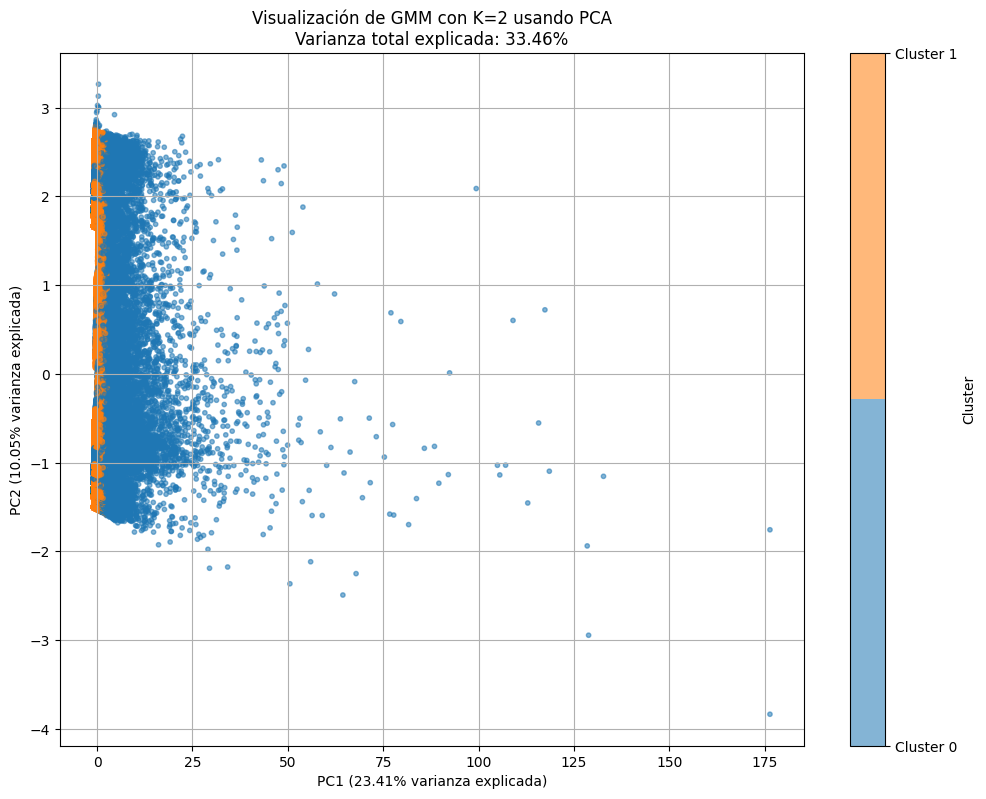

In [37]:
from matplotlib.colors import ListedColormap

# VISUALIZAR CLUSTERS EN EL ESPACIO PCA

cmap_2 = ListedColormap(["#1f77b4", "#ff7f0e"])

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap=cmap_2,
    alpha=0.55,
    s=10
)

plt.xlabel(f"PC1 ({pc1_var:.2f}% varianza explicada)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% varianza explicada)")

plt.title(
    f"Visualización de GMM con K=2 usando PCA\n"
    f"Varianza total explicada: {total_var:.2f}%"
)

cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.set_label("Cluster")
cbar.set_ticklabels(["Cluster 0", "Cluster 1"])

plt.grid(True)
plt.show()

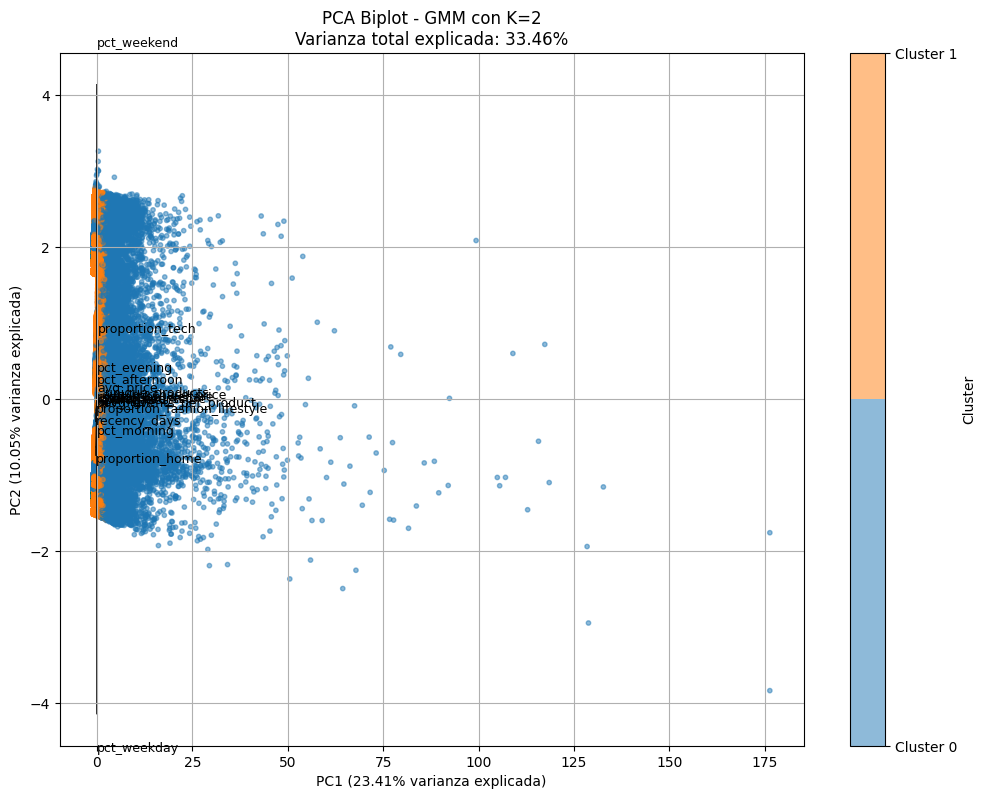

In [38]:
# ============================================================
# PCA BIPLOT CON LOADINGS Y ZOOM
# ============================================================

plt.figure(figsize=(12, 9))

# Scatter de usuarios
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap=cmap_2,
    alpha=0.5,
    s=10
)

# ============================================================
# LOADINGS
# ============================================================

loadings = pca.components_.T
feature_names = X.columns

scale_factor = 6

for i, feature in enumerate(feature_names):

    x_vector = loadings[i, 0] * scale_factor
    y_vector = loadings[i, 1] * scale_factor

    # Flecha
    plt.arrow(
        0,
        0,
        x_vector,
        y_vector,
        color="black",
        alpha=0.8,
        head_width=0.08,
        length_includes_head=True
    )

    # Nombre de variable
    plt.text(
        x_vector * 1.12,
        y_vector * 1.12,
        feature,
        fontsize=9,
        color="black"
    )

# ============================================================
# LIMITAR RANGO (ZOOM)
# ============================================================

#plt.xlim(x_min, x_max)
#plt.ylim(y_min, y_max)

# ============================================================
# ETIQUETAS
# ============================================================

plt.xlabel(f"PC1 ({pc1_var:.2f}% varianza explicada)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% varianza explicada)")

plt.title(
    f"PCA Biplot - GMM con K=2\n"
    f"Varianza total explicada: {total_var:.2f}%"
)

# ============================================================
# COLORBAR
# ============================================================

cbar = plt.colorbar(scatter, ticks=[0, 1])

cbar.set_label("Cluster")
cbar.set_ticklabels(["Cluster 0", "Cluster 1"])

# ============================================================
# GRID
# ============================================================

plt.grid(True)

plt.show()